# ATLAS v1

## LLM-Based Knowledge Extraction and Knowledge Graph Construction

Agentic Text and Literature Analysis System

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root / "src"))

In [2]:
# Imports

import networkx as nx
import matplotlib.pyplot as plt

from atlas.extractors import MistralExtractor
from atlas.graph_builder import GraphBuilder

from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("MISTRAL_API_KEY")

In [3]:
# Load Paper

from atlas.io import load_text

text = load_text(
    "../data/papers/autokaggle.txt"
)

In [4]:
# LLM-Based Knowledge Extraction

extractor = MistralExtractor(
    api_key=api_key
)

result = extractor.extract(text)

result

ExtractionResult(entities=[Entity(name='AutoKaggle', type='Framework'), Entity(name='Kaggle', type='Benchmark'), Entity(name='Multi-Agent System', type='ScientificConcept'), Entity(name='Data Cleaning', type='ScientificConcept'), Entity(name='Feature Engineering', type='ScientificConcept'), Entity(name='Modeling', type='ScientificConcept'), Entity(name='Unit Testing', type='ScientificConcept')], relationships=[Relationship(source='AutoKaggle', relation='implements', target='Multi-Agent System'), Relationship(source='AutoKaggle', relation='integrates', target='Data Cleaning'), Relationship(source='AutoKaggle', relation='integrates', target='Feature Engineering'), Relationship(source='AutoKaggle', relation='integrates', target='Modeling'), Relationship(source='AutoKaggle', relation='implements', target='Unit Testing'), Relationship(source='AutoKaggle', relation='evaluates', target='Kaggle')])

In [5]:
print(f"Entities: {len(result.entities)}")
print(f"Relationships: {len(result.relationships)}")

Entities: 7
Relationships: 6


In [6]:
# Build Knowledge Graph

builder = GraphBuilder()

graph = builder.build(result)

In [7]:
# Graph Statistics

print(f"Nodes: {graph.number_of_nodes()}")
print(f"Edges: {graph.number_of_edges()}")

Nodes: 7
Edges: 6


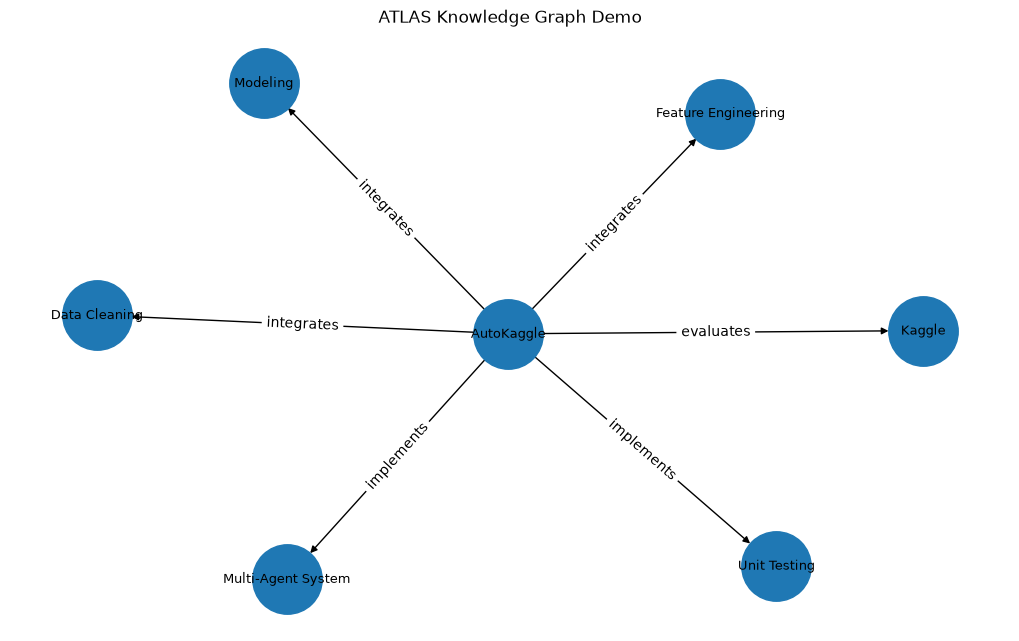

In [8]:
# Visualization

plt.figure(figsize=(10, 6))

pos = nx.spring_layout(
    graph,
    seed=42
)

nx.draw(
    graph,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)

edge_labels = nx.get_edge_attributes(
    graph,
    "relation"
)

nx.draw_networkx_edge_labels(
    graph,
    pos,
    edge_labels=edge_labels
)

plt.title(
    "ATLAS Knowledge Graph Demo"
)

plt.show()

In [9]:
# Export Graph

import json
import networkx as nx

with open("graph.json", "w") as f:
    json.dump(
        nx.node_link_data(graph),
        f,
        indent=2
    )

In [10]:
nx.write_graphml(graph, "atlas_graph.graphml")